# Shared-B variant

Imported from the paper-1 repo and switched to this repo's live design:
`shared_loadings=True` on every `DesignSpec`, so one loading matrix $B$ is drawn once at
$p_{\max}$ and **every** replicate is scored against that same truth, with $p$ walking its
prefixes — the design the paper text describes ("this loading matrix $B$ is fixed for all
1000 paths"). The source notebooks redrew $B$ per replicate, averaging over universes.

The factor and idiosyncratic draws are bit-identical between the two designs, so the
$B$-free theory quantities (`floor`, `rhs`, `rotation`) are unchanged; only the loading
geometry moves. Caches and figure outputs use `*_sharedB` / `*-sharedB` paths so the two
variants never collide.

> **Known discrepancy — the $\hat\nu$ limit.** This notebook's local `Eq6RHSWithNu`
> derives `c_half` from the realized, $p$-truncated loadings
> (`(context.model.B ** 2).mean(axis=1)`), whereas the shared `Eq6RHSAnalysis` in `sim/`
> — and `ex-9` — use the **fixed population** GB diagonal and explicitly warn against
> re-deriving it empirically (see that class's docstring: a finite-$p$ estimate is noisy
> and biased for small $p$, and leaks $p$-dependence into quantities the theorem defines
> as $p$-independent). Upstream, the GB-constant fix reached `ex-9` but not the radar/disk
> notebooks, which were added in the commit after it. This affects only the $\hat\nu$
> reference panels/points, most visibly at small $p$. **Ported unchanged** so the figures
> reproduce what was seen before; worth resolving before these are relied on.


# ex-10 two-factor paired radar — replicates you can point at

The $k=2$ disk from `ex-8`, redrawn so that **an individual replicate keeps its identity**
across every panel. At $k=2$ the population subspace is a single plane, so the pair
$(\langle b_1,h_j\rangle, \langle b_2,h_j\rangle)$ is the whole estimate — nothing hides in a
third coordinate. What `ex-8` could not show is *which dot is which*: each panel was an
anonymous cloud, so "what happens to this replicate as $p$ grows" had no visual answer.

The whole notebook is about two numbers, both read straight off that picture:

| quantity | what it is | whose it is |
|---|---|---|
| $\lVert\Pi h_j\rVert$ | how much of each estimate survives the projection; equivalently $\cos$ of its tilt out of the plane | **$n$'s** — it converges to $\sqrt{1-\text{floor}_j}$ and $p$ never touches it |
| $\angle(\Pi h_1, \Pi h_2)$ | how far from square the projected pair sits | **$p$'s** — centred on $90°$ always, with the departure decaying like $1/\sqrt{p}$ |

Figure 1 shows both for single replicates, Figure 2 for all 1,000, and Figure 3 for seven
named replicates side by side.

The sweep is the `ex-8` model and design exactly (same $k$, vols, $\beta$ samplers, tails,
seed, $p$ grid, $R=1000$), with **one change that this notebook depends on**: the population
frame $b$ is *gauge-fixed* (next section). Sampling is nested in $p$ and in time, so
replicate $r$ at $p=100$ is a strict asset subset of the same replicate at $p=50{,}000$ —
tracking a replicate across the strip is following one draw, not comparing distributions.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from fl_plot import save as fl_save, THEME

DATA_DIR = REPO_ROOT / "nb_outputs"
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR = DATA_DIR / "ex10_paired_radar-sharedB"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """Figure path: OUT_DIR/stem when saving is on (globally via SAVE_FIGS,
    or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


def finish(fig, suptitle, caption, *, stem=None, save=None, y=1.0):
    """House styling: navy suptitle, gray caption under the axes, then save+show."""
    fig.suptitle(suptitle, color=THEME.navy, y=y)
    fig.text(0.5, -0.02, caption + f"   Per-replicate marks use R = {N_REPS}.",
             ha="center", va="top", fontsize=THEME.caption_fontsize,
             color=THEME.gray, wrap=True)
    path = out(stem, save) if stem else None
    if path is not None:
        fl_save(fig, path, formats=FIG_FORMATS)
    show(fig)


K = 2
model = ModelSpec(
    k_factors=K,
    factor_vols=[0.16, 0.08],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511
P_STEPS = [100, 500, 5000, 10000, 20000, 50000]
P_MAX = max(P_STEPS)
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"
print("ready")

ready


## Gauge fixing — why `ex-8`'s coordinates cannot identify a replicate

The coordinates are $\langle b_i, h_j \rangle$, and both vectors come out of an
eigendecomposition, so **both carry an arbitrary sign**. `ex-8` folds $h_j$ (by its dominant
coordinate) but leaves the population frame alone, and `b_pop` is re-decomposed at every
$(\text{rep}, p)$ cell — so $b_2$ may point one way for replicate 7 and the other way for
replicate 8, and one way at $p=500$ and the other at $p=5000$. The *magnitudes* survive
(which is why `ex-8`'s clouds and boxplots are correct), but the **sign of the off-axis
coordinate is scrambled**, and with it any notion of "the same point, one panel later".

The fix costs two lines. The loading rows $\ell_i = B_i/\lVert B_i\rVert$ have no sign
freedom — $B$ is drawn, not diagonalized — so they pin the frame:

$$b_i \;\leftarrow\; \operatorname{sign}\!\left(\langle b_i, \ell_i\rangle\right)\, b_i,
\qquad h_j \;\leftarrow\; \operatorname{sign}\!\left(\langle b_j, h_j\rangle\right)\, h_j$$

and the same own-coordinate-positive convention is applied to $\hat\nu$.

Flipping $b_2$ flips the sign of the off-axis coordinate, hence of the tilt $\theta_j$, for
both factors at once — so under the unfixed convention every *magnitude* survives intact
while every per-replicate *sign* is re-tossed at each $(\text{rep}, p)$ cell. The check cell
below measures both sides, by scrambling this notebook's own gauge back:

| correlation over the 1,000 replicates | scrambled gauge | gauge fixed |
|---|---|---|
| $\theta_1$ at $p=50{,}000$ vs its own limit $\theta_\infty$ | $\approx 0$ | $\mathbf{1.00}$ |
| $\theta_1$ at $p=100$ vs $\theta_1$ at $p=50{,}000$ | $\approx 0$ | $\mathbf{0.80}$ |

Read directly off `ex-8`'s cache — whose convention *is* the unfixed one — those two come out
at $0.00$ and $0.05$, i.e. the real damage is as bad as the random-sign bound. Nothing about
the estimator changed here: `ex-8`'s clouds, boxplots and $\sin^2$ tables are all correct,
because they only ever consume magnitudes. What they could not do was say *which dot*.

In [2]:
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment
from fl_experiment_setup import BaseExperiment


class Eq6RHSWithNu(Eq6RHSAnalysis):
    """Eq6RHSAnalysis plus the eigenvector coordinates of the k x k realized Gram,
    gauge-fixed to own-coordinate-positive so nu_j is comparable across replicates."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        F = context.factor_returns.T
        if self.center:
            F = F - F.mean(axis=1, keepdims=True)
        c_half = np.sqrt((context.model.B ** 2).mean(axis=1))
        D_hat = (c_half[:, None] * (F @ F.T / context.T)) * c_half[None, :]
        vals, vecs = np.linalg.eigh(D_hat)
        V = vecs[:, np.argsort(vals)[::-1]]                  # (k, k), col j = nu_j
        result["nu_coords"] = V * np.where(np.diag(V) < 0, -1.0, 1.0)[None, :]
        return result


class GaugedProjectedSpectrum:
    """Dual-Gram PCA with the eq.(18) split AND gauge-fixed projection coordinates.

    The population frame is sign-locked to the loading rows (``loading_frame``)
    before any coordinate is taken, and each estimate is then sign-locked to its
    own population direction. Both conventions are deterministic functions of
    quantities that have no sign freedom, so a coordinate means the same thing in
    every replicate and at every p.
    """

    def __init__(self, b_pop, loading_frame, center: bool = True):
        s = np.sign((b_pop * loading_frame).sum(axis=1))
        self.b = np.where(s == 0, 1.0, s)[:, None] * b_pop   # gauge-fixed b frame
        self.ell, self.center = loading_frame, center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        eigenvalues, eigenvectors = np.linalg.eigh(Y.T @ Y)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, _ = compute_sine_alignment(self.b, H.T)
        C = self.b @ H                                        # (k, k), col j = Pi h_j
        C = C * np.where(np.diag(C) < 0, -1.0, 1.0)[None, :]  # own coordinate positive
        return {"sin2_j": sin2_angle,
                "oos": 1.0 - (C ** 2).sum(axis=0),            # ||Pi_perp h_j||^2
                "h_coords": C,
                # how far the population frame itself has rotated off the loading
                # rows at this p — the O(1/sqrt(p)) tilt of the reference itself.
                "frame_tilt": float(abs(self.b[0] @ self.ell[1]))}


class PairedFrameExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        ell = model.B / np.linalg.norm(model.B, axis=1, keepdims=True)
        return [GaugedProjectedSpectrum(b_pop, ell, center=self.center),
                Eq6RHSWithNu(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        C, W = merged["h_coords"], merged["nu_coords"]
        k = C.shape[0]
        return [{
            "n": n, "p": p, "j": j + 1,
            "sin2_j": float(merged["sin2_j"][j]),
            "rhs": float(merged["rhs"][j]), "floor": float(merged["floor"][j]),
            "rotation": float(merged["rotation"][j]),
            "oos": float(merged["oos"][j]),
            "frame_tilt": merged["frame_tilt"],
            **{f"hb{i + 1}": float(C[i, j]) for i in range(k)},
            **{f"nu{i + 1}": float(W[i, j]) for i in range(k)},
        } for j in range(k)]


print("experiment classes defined")

experiment classes defined


In [3]:
design_p = DesignSpec(
    n_values=[63], p_values=P_STEPS,
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True,
    shared_loadings=True, **HEAVY_TAIL,
)

_REQ = {"rep", "hb1", "hb2", "nu1", "nu2", "oos", "frame_tilt"}
import json as _json


def _spec_fingerprint(design):
    # Everything that determines the numbers — model, design, AND the gauge
    # convention (bumping "gauge" invalidates every cache built before it).
    return _json.dumps({
        "gauge": "b<-sign(<b_i,l_i>), h<-sign(<b_j,h_j>), nu<-sign(nu_jj)",
        "k": model.k_factors, "vols": list(model.factor_vols),
        "betas": model.beta_samplers, "idio": model.idio_vol_sampler,
        "n": list(design.n_values), "p": list(design.p_values),
        "reps": design.n_reps, "seed": design.random_seed,
        "shared_loadings": design.shared_loadings,
        "tails": HEAVY_TAIL}, sort_keys=True)


def load_or_run(path, design, label):
    spec = _spec_fingerprint(design)
    sidecar = path.with_suffix(".spec.json")
    if path.exists() and sidecar.exists() and sidecar.read_text() == spec:
        d = pd.read_parquet(path)
        if _REQ <= set(d.columns):
            print(f"{label}: loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
    if path.exists():
        print(f"{label}: cache stale (spec changed) — re-running")
    d = run_experiment(model, design, PairedFrameExperiment(), progress=True)
    d.to_parquet(path)
    sidecar.write_text(spec)
    print(f"{label}: ran sweep ({len(d):,} rows) -> {path.name}")
    return d


df = load_or_run(DATA_DIR / "ex10_sharedB_df_p.parquet", design_p, "growing-p")

replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 1/1000 [00:00<03:08,  5.31rep/s]

replicate:   0%|          | 2/1000 [00:00<02:21,  7.05rep/s]

replicate:   0%|          | 3/1000 [00:00<02:07,  7.82rep/s]

replicate:   0%|          | 4/1000 [00:00<01:59,  8.37rep/s]

...

replicate: 100%|█████████▉| 998/1000 [01:51<00:00,  8.93rep/s]

replicate: 100%|█████████▉| 999/1000 [01:51<00:00,  8.91rep/s]

replicate: 100%|██████████| 1000/1000 [01:51<00:00,  8.98rep/s]

replicate: 100%|██████████| 1000/1000 [01:51<00:00,  8.97rep/s]

growing-p: ran sweep (12,000 rows) -> ex10_sharedB_df_p.parquet


## Derived quantities — one signed angle per estimate

Because the frame is gauge-fixed, each estimate reduces to a **radius** and a **signed
angle**, both meaningful across replicates:

- $\;r_j = \lVert \Pi h_j \rVert = \sqrt{1 - \lVert\Pi^{\perp}h_j\rVert^2}\;$ — how much of
  the estimate survives the projection; the deficit is the $n$-driven floor, which growing
  $p$ does **not** remove.
- $\;\theta_j\;$ — the tilt of $h_j$ off its *own* axis $b_j$, signed in the common
  $b_1 \to b_2$ sense, so $\theta_1$ and $\theta_2$ are directly comparable: if the estimated
  frame is a **rotation** of the true frame, $\theta_1 = \theta_2$.
- $\;\theta_{\infty}\;$ — the same angle for $\hat\nu_j$, the eigenvector of the replicate's
  realized $k\times k$ factor Gram. This is the $p\to\infty$ destination, fixed by the
  replicate's own $F$ draw.

Figure 2 shows that these are not two arbitrary summaries but the two halves of one frame
comparison: $\theta$ is the rotation factor of the projected frame and $r_j = \cos\varphi_j$
its shrink factor, where $\varphi_j$ are the principal angles between the two planes.

In [4]:
def derive(d):
    C = d[["hb1", "hb2"]].to_numpy()
    W = d[["nu1", "nu2"]].to_numpy()
    j = d["j"].to_numpy()
    # signed angle off the own axis, measured in the common b_1 -> b_2 sense:
    # for j=1 that is (own, perp) = (hb1, hb2); for j=2 it is (hb2, -hb1).
    own = np.where(j == 1, C[:, 0], C[:, 1])
    perp = np.where(j == 1, C[:, 1], -C[:, 0])
    own_nu = np.where(j == 1, W[:, 0], W[:, 1])
    perp_nu = np.where(j == 1, W[:, 1], -W[:, 0])
    return d.assign(
        rad=np.hypot(C[:, 0], C[:, 1]),                       # ||Pi h_j||
        tilt=np.degrees(np.arctan2(perp, own)),               # theta_j
        tilt_nu=np.degrees(np.arctan2(perp_nu, own_nu)),      # theta_inf at this p
        sin2_in=1.0 - own ** 2 / (C ** 2).sum(axis=1),
    )


df = derive(df)
# The replicate key: its limiting tilt, read off nu at the largest p. One number per
# replicate, independent of the panel it is drawn in.
theta_lim = df[(df.p == P_MAX) & (df.j == 1)].set_index("rep")["tilt_nu"].rename("theta_lim")
df = df.merge(theta_lim, left_on="rep", right_index=True)

_w = df.pivot_table(index=["rep", "p"], columns="j", values="tilt").rename(columns="t{}".format)
print(f"|r^2 - (1 - oos)| max = {(df.rad ** 2 - (1 - df.oos)).abs().max():.2e}   (radius identity)")
print(f"|sin2_in - rotation| median at p={P_MAX:,}: "
      f"{(df[df.p == P_MAX].sin2_in - df[df.p == P_MAX].rotation).abs().median():.2e}   "
      "(in-subspace rotation has reached its limit)")
print("\nWhat the gauge buys, as correlations over the R = 1,000 replicates:")
_t = pd.DataFrame({
    "corr(theta_1, theta_2)": _w.groupby("p").apply(lambda g: g.t1.corr(g.t2), include_groups=False),
    "corr(theta_1, theta_inf)": df[df.j == 1].groupby("p").apply(lambda g: g.tilt.corr(g.theta_lim), include_groups=False),
    "corr(theta_2, theta_inf)": df[df.j == 2].groupby("p").apply(lambda g: g.tilt.corr(g.theta_lim), include_groups=False),
}).round(3)
_t.index = [f"{v:,}" for v in _t.index]
display(_t)
print("theta_1 across p (same replicate, nested sub-samples):")
_x = df[df.j == 1].pivot(index="rep", columns="p", values="tilt").corr().round(3)
_x.index = _x.columns = [f"{v:,}" for v in _x.columns]
display(_x)

# The same two statistics with the gauge scrambled back: an arbitrary sign on b_2,
# redrawn per (rep, p) — which is what re-decomposing the population frame in every
# cell amounts to. It flips theta for both factors together and nothing else.
_flip = pd.Series(np.random.default_rng(0).choice([-1.0, 1.0], size=(df.rep.nunique(), len(P_STEPS))).ravel(),
                  index=pd.MultiIndex.from_product([sorted(df.rep.unique()), P_STEPS], names=["rep", "p"]))
_scr = df.assign(tilt_scr=df.tilt * _flip.reindex(pd.MultiIndex.from_frame(df[["rep", "p"]])).to_numpy())
_s1 = _scr[_scr.j == 1]
print("\nSame statistics with the gauge scrambled back (arbitrary sign on b_2 per rep and p):")
display(pd.DataFrame({
    "corr(theta_1, theta_inf)": _s1.groupby("p").apply(lambda g: g.tilt_scr.corr(g.theta_lim), include_groups=False),
    f"corr(theta_1 here, theta_1 at p={P_MAX:,})":
        _s1.pivot(index="rep", columns="p", values="tilt_scr").corr()[P_MAX],
}).round(3).set_axis([f"{v:,}" for v in P_STEPS]))

|r^2 - (1 - oos)| max = 2.22e-16   (radius identity)
|sin2_in - rotation| median at p=50,000: 1.06e-04   (in-subspace rotation has reached its limit)

What the gauge buys, as correlations over the R = 1,000 replicates:


,"corr(theta_1, theta_2)","corr(theta_1, theta_inf)","corr(theta_2, theta_inf)"
100,0.548,0.806,0.411
500,0.973,0.967,0.939
"5,000",0.999,0.996,0.995
"10,000",1.000,0.998,0.998
"20,000",1.000,0.999,0.999
"50,000",1.000,1.000,1.000


theta_1 across p (same replicate, nested sub-samples):


,100,500,"5,000","10,000","20,000","50,000"
100,1.000,0.836,0.810,0.808,0.807,0.806
500,0.836,1.000,0.971,0.969,0.968,0.967
"5,000",0.810,0.971,1.000,0.998,0.997,0.997
"10,000",0.808,0.969,0.998,1.000,0.999,0.998
"20,000",0.807,0.968,0.997,0.999,1.000,0.999
"50,000",0.806,0.967,0.997,0.998,0.999,1.000



Same statistics with the gauge scrambled back (arbitrary sign on b_2 per rep and p):


,"corr(theta_1, theta_inf)","corr(theta_1 here, theta_1 at p=50,000)"
100,-0.005,-0.032
500,-0.055,0.010
"5,000",0.030,-0.086
"10,000",0.010,-0.070
"20,000",0.006,-0.043
"50,000",0.099,1.000


## Figure 1 — the two projections, and the angle between them

The plainest possible view, and the place to start. Take one replicate, project its two
estimates onto the population plane, and draw the results: $\Pi h_1$ and $\Pi h_2$ as
arrows in the $(b_1, b_2)$ plane, at true scale, with the angle between them marked. The
grey circle is the unit circle — where the arrows *would* reach if $h_1$ and $h_2$ lay
entirely inside the plane. The histogram underneath is that angle over all 1,000 replicates.

**What to look for:** two facts that are easy to conflate and are in fact independent.

1. **The arrows are short, and unequally so.** $\Pi h_1$ reaches $\approx 0.95$, $\Pi h_2$
   only $\approx 0.83$. That shortfall is not the plane being squashed — an orthogonal
   projection acts as the *identity* on its own plane. It is the shadow of a unit vector
   that is tilted out of the plane, so the arrow length is the cosine of that tilt.
   The tilts are $16°$ and $33°$: the two principal angles of Figure 2.
2. **The angle between them stays square anyway.** It is centred on $90°$ at every $p$, and
   the spread collapses fast — s.d. $6.7°$ at $p=100$, $0.16°$ at $p=5{,}000$, $0.05°$ at
   $p=50{,}000$. Note the histogram's x-axis range shrinks by more than a hundredfold across
   the strip; each panel prints its own s.d.

Severe unequal shortening with the right angle preserved is not a contradiction: an
anisotropic contraction preserves the angle between its *own* principal axes, and Figure 2
shows those axes are $(h_1, h_2)$ themselves.

**The middle row is the worst case at $p=100$** — the replicate whose two projections open
the widest angle there, $155.1°$. Look at why: $\lVert\Pi h_2\rVert$ is $0.203$, so $96\%$
of $h_2$'s mass lies outside the plane ($\sin^2 = 0.994$). At that width the replicate has
not identified a second factor at all, and a direction with almost nothing left inside the
plane has almost nothing constraining where its shadow points — the angle is free to be
anything. This is what the far tails of the $p=100$ histogram are made of: 93 of the 12,000
(replicate, $p$) cells have $\lVert\Pi h_j\rVert < 0.55$, and 92 of the 93 are $h_2$. One step to $p=500$ and it is back
to $91.1°$ with $\lVert\Pi h_2\rVert = 0.806$; by $p=5{,}000$ it reads $90.09°$ and is
indistinguishable from the typical replicate above it. The opposite extreme at $p=100$ is
replicate 673, whose two projections come within $0.57°$ of *parallel*.

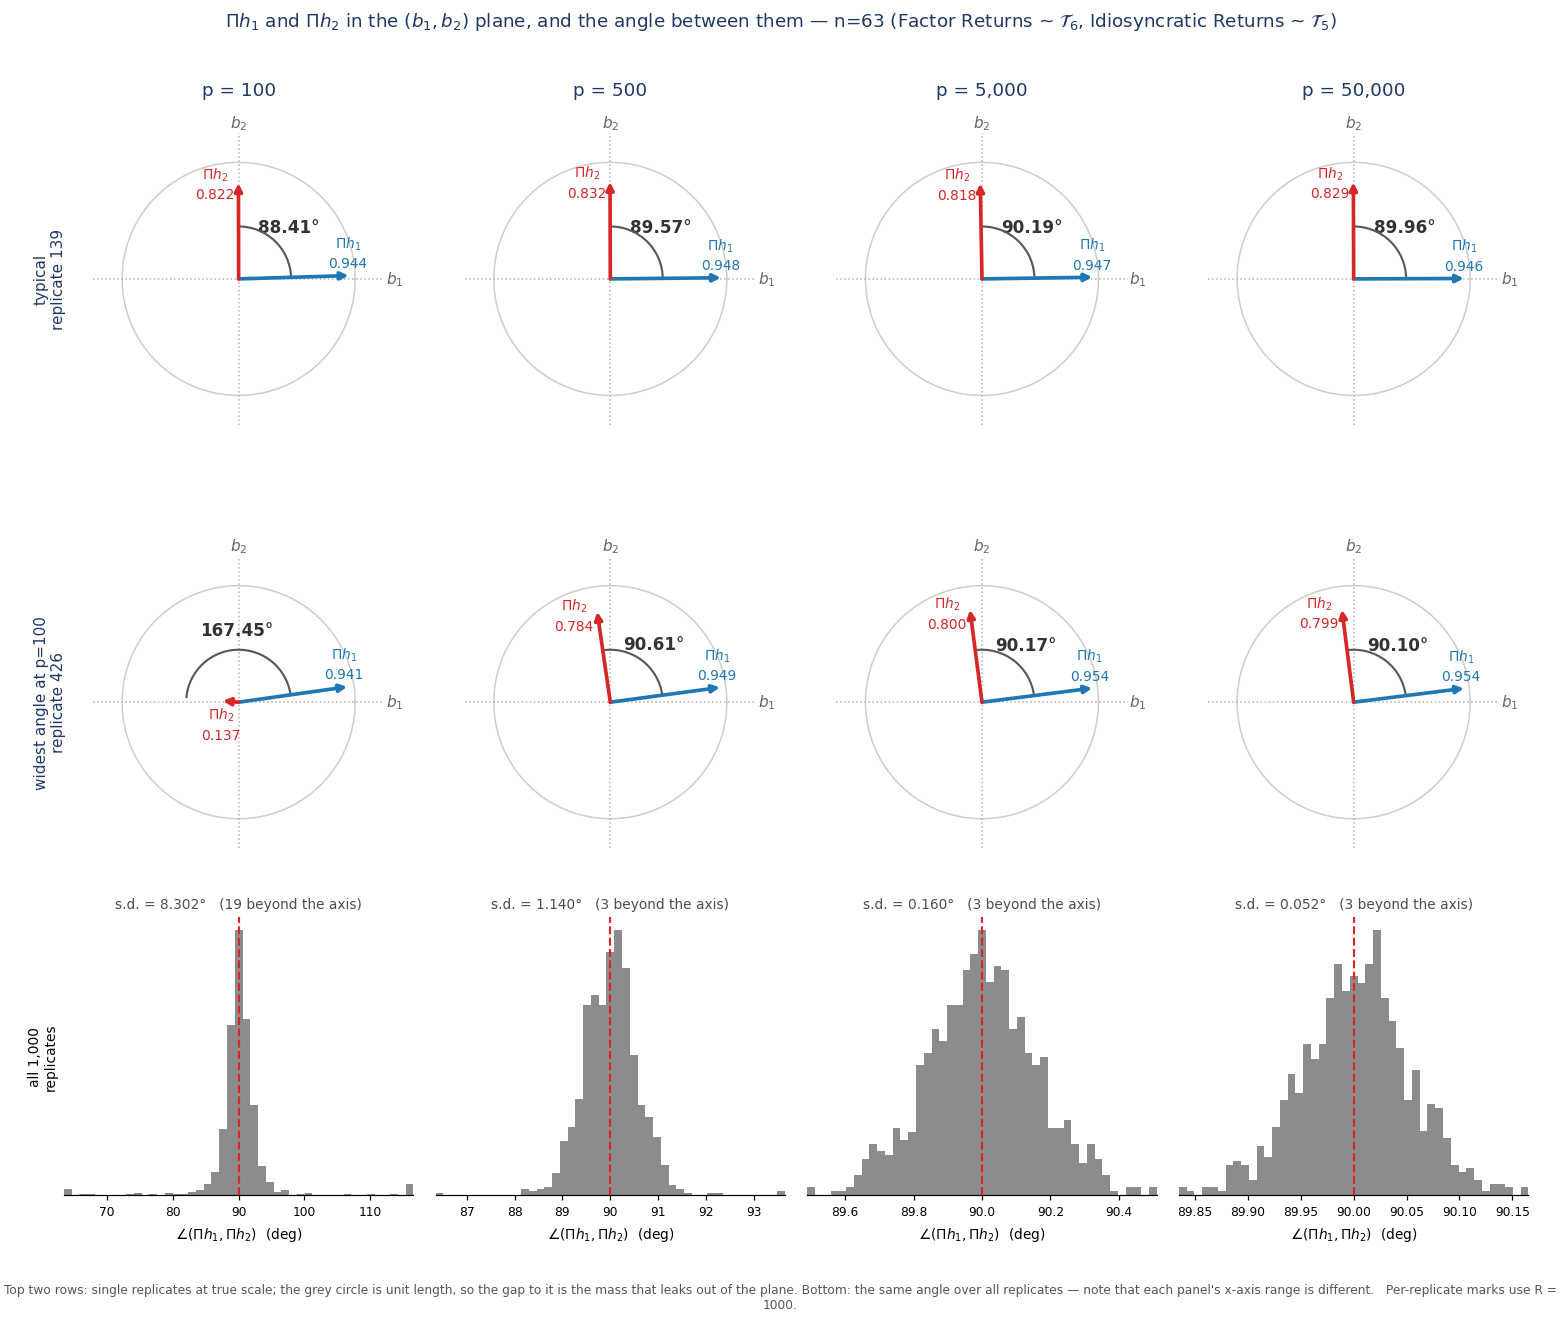

In [5]:
from matplotlib.patches import Arc

_PS_SIMPLE = [100, 500, 5000, P_MAX]
_PAIR = df.pivot_table(index=["rep", "p"], columns="j", values=["hb1", "hb2"])
_PAIR.columns = [f"{a}_j{b}" for a, b in _PAIR.columns]
_PAIR = _PAIR.reset_index()
_u = _PAIR[["hb1_j1", "hb2_j1"]].to_numpy()
_v = _PAIR[["hb1_j2", "hb2_j2"]].to_numpy()
_PAIR["ang"] = np.degrees(np.arccos(np.clip(
    (_u * _v).sum(1) / (np.linalg.norm(_u, axis=1) * np.linalg.norm(_v, axis=1)), -1, 1)))

# a representative replicate: the one whose limiting rotation is closest to the median
_med = df.groupby("rep").theta_lim.first()
_REP = int((_med - _med.median()).abs().idxmin())
_C1, _C2 = "#1f77b4", "#d62728"
# a representative replicate (top row) and the p=100 extreme (middle row): the
# replicate whose two projections open the widest angle at the narrowest p.
_a100 = _PAIR[_PAIR.p == 100]
_REP_MAX = int(_a100.loc[_a100.ang.idxmax(), "rep"])


def _draw_pair(ax, e):
    """One replicate's two projections as arrows in the (b_1, b_2) plane, true scale."""
    t = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(t), np.sin(t), color="#CFCDC6", lw=1.0, zorder=1)
    ax.plot([-1.25, 1.25], [0, 0], ":", color="0.7", lw=1.0, zorder=1)
    ax.plot([0, 0], [-1.25, 1.25], ":", color="0.7", lw=1.0, zorder=1)
    ax.text(1.34, 0, r"$b_1$", color="0.4", fontsize=10, ha="center", va="center")
    ax.text(0, 1.34, r"$b_2$", color="0.4", fontsize=10, ha="center", va="center")
    a1 = np.degrees(np.arctan2(e.hb2_j1, e.hb1_j1))
    a2 = np.degrees(np.arctan2(e.hb2_j2, e.hb1_j2))
    ax.add_patch(Arc((0, 0), 0.9, 0.9, theta1=min(a1, a2), theta2=max(a1, a2),
                     color="0.35", lw=1.4, zorder=4))
    for (x, y), col, lab in (((e.hb1_j1, e.hb2_j1), _C1, r"$\Pi h_1$"),
                             ((e.hb1_j2, e.hb2_j2), _C2, r"$\Pi h_2$")):
        ax.annotate("", xy=(x, y), xytext=(0, 0), zorder=5,
                    arrowprops=dict(arrowstyle="-|>", color=col, lw=2.4, shrinkA=0, shrinkB=0))
        nrm = np.hypot(x, y)
        px, py = -y / nrm, x / nrm          # label offset perpendicular to the arrow
        ax.text(x + 0.20 * px, y + 0.20 * py, f"{lab}\n{nrm:.3f}", color=col, fontsize=9,
                ha="center", va="center", linespacing=1.4)
    am = np.radians((a1 + a2) / 2)
    ax.text(0.62 * np.cos(am), 0.62 * np.sin(am), f"{e.ang:.2f}°", fontsize=11,
            color="0.2", ha="center", va="center", fontweight="bold")
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.set_aspect("equal")
    ax.axis("off")


fig, axes = plt.subplots(3, len(_PS_SIMPLE), figsize=(14.0, 11.4),
                         gridspec_kw=dict(height_ratios=[1.5, 1.5, 1.0]))
for _ri, (_rep_id, _row_lab) in enumerate(
        ((_REP, f"typical\nreplicate {_REP}"),
         (_REP_MAX, f"widest angle at p=100\nreplicate {_REP_MAX}"))):
    for _ci, _v_p in enumerate(_PS_SIMPLE):
        ax = axes[_ri, _ci]
        _draw_pair(ax, _PAIR[(_PAIR.rep == _rep_id) & (_PAIR.p == _v_p)].iloc[0])
        if _ri == 0:
            ax.set_title(f"p = {_v_p:,}", color=THEME.navy, fontsize=12)
        if _ci == 0:
            ax.text(-1.62, 0, _row_lab, rotation=90, fontsize=10, color=THEME.navy,
                    ha="center", va="center", clip_on=False)

for _ci, _v_p in enumerate(_PS_SIMPLE):
    ax = axes[2, _ci]
    sa = _PAIR[_PAIR.p == _v_p].ang
    sd = float(sa.std())
    lo, hi = 90 - 3.2 * sd, 90 + 3.2 * sd
    ax.hist(sa.clip(lo, hi), bins=45, range=(lo, hi), color="0.55", lw=0)
    ax.axvline(90, color=_C2, ls="--", lw=1.4)
    ax.set_xlim(lo, hi)
    ax.set_yticks([])
    ax.set_xlabel(r"$\angle(\Pi h_1, \Pi h_2)$  (deg)", fontsize=9)
    ax.tick_params(labelsize=8)
    _out = int(((sa < lo) | (sa > hi)).sum())
    ax.set_title(f"s.d. = {sd:.3f}°" + (f"   ({_out} beyond the axis)" if _out else ""),
                 fontsize=9, color="0.3")
    for _sp in ("top", "right", "left"):
        ax.spines[_sp].set_visible(False)
axes[2, 0].set_ylabel("all 1,000\nreplicates", fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.96))
finish(fig,
       rf"$\Pi h_1$ and $\Pi h_2$ in the $(b_1, b_2)$ plane, and the angle between them "
       rf"— n=63 {_TAILS}",
       "Top two rows: single replicates at true scale; the grey circle is unit length, so "
       "the gap to it is the mass that leaks out of the plane. Bottom: the same angle over "
       "all replicates — note that each panel's x-axis range is different.",
       stem="ex10_two_projections", y=0.995)

## Figure 2 — the length and the angle, over all 1,000 replicates

Figure 1 showed two individual replicates. Here are its two quantities over the whole
ensemble; between them they are the entire story of the projected pair.

- **Length** $\lVert\Pi h_j\rVert$ — how much of each estimate survives the projection. The
  right-hand axis reads the same number as a tilt out of the plane, $\arccos$ of the length.
- **Angle** $\angle(\Pi h_1, \Pi h_2)$ — how far from square the projected pair sits.

**What to look for.**

1. **The lengths are unequal, and they stop moving.** $\lVert\Pi h_1\rVert \approx 0.960$ at
   every $p$; $\lVert\Pi h_2\rVert$ climbs from $0.770$ to $0.835$ and then stops dead on
   $\sqrt{1-\text{floor}_2}$. Growing $p$ removes the finite-$p$ noise — the long lower tail
   on the $p=100$ box — and nothing else. What remains is $n$'s floor,
   $\text{floor}_j = \delta^2/(n\rho_j + \delta^2)$, and factor 2's spike is $5\times$ weaker
   ($\rho = 0.032$ vs $0.0064$), so its floor is about $4\times$ bigger. Read on the right
   axis: $h_1$ sits $16°$ out of the plane, $h_2$ sits $33°$.
2. **The angle is square, and gets squarer.** Median $90.00°$ from $p=500$ on, with the
   spread collapsing around it.
3. **It squares up at exactly $1/\sqrt{p}$.** The right panel is $|\angle - 90°|$ on a log
   scale; the fitted slope is $-0.507$ for $p \ge 5{,}000$. That rate is the fingerprint of
   the mechanism: orthogonality in $\mathbb{R}^p$ forces
   $\langle \Pi h_1, \Pi h_2\rangle = -\langle \Pi^{\perp} h_1, \Pi^{\perp} h_2\rangle$, and
   the two out-of-plane residuals are effectively independent directions in $p-2$ dimensions,
   so their overlap decays like $1/\sqrt{p}$ — even though the residuals themselves stay
   large ($30\%$ of $h_2$'s mass).

**The two effects have different sources and different fates: the length deficit is $n$'s and
$p$ never touches it; the angle defect is $p$'s and vanishes.**

Why severe unequal shortening still leaves a right angle: write the projected frame as
$C = R(\theta)\,S$ with $S$ symmetric. An anisotropic contraction does not preserve angles in
general, but it does preserve the angle between its *own* principal axes — and the cell below
prints $S$'s off-diagonal, which is $0.0000$ to four places. The contraction's principal axes
are $(h_1, h_2)$ themselves, so the pair is shortened unequally *along its own axes*, which
shortens without shearing.

leading right-singular vector aligned with h_1: |v_11| mean 0.9993, min 0.1087
largest principal angle ever seen: 89.451 deg (100.00% of cells strictly below 90)
angle(Pi h_1, Pi h_2): mean 90.059 deg, 48.0% below 90 (a coin flip — not a.s. below)

the shrink factor S = V diag(sigma) V^T in the (h_1, h_2) basis — off-diagonal is the shear:


s11             s22             s12        
          mean     std    mean     std    mean     std
100     0.9568  0.0269  0.7224  0.1512 -0.0013  0.0201
500     0.9585  0.0107  0.8318  0.0466 -0.0001  0.0052
5,000   0.9592  0.0101  0.8329  0.0314 -0.0000  0.0012
10,000  0.9592  0.0101  0.8335  0.0310 -0.0000  0.0009
20,000  0.9592  0.0100  0.8336  0.0309 -0.0000  0.0006
50,000  0.9592  0.0100  0.8356  0.0304 -0.0000  0.0004

log-log slope of median |angle - 90| against p: -0.557 (all p), -0.516 (p >= 5,000); -0.5 is the independent-residual prediction


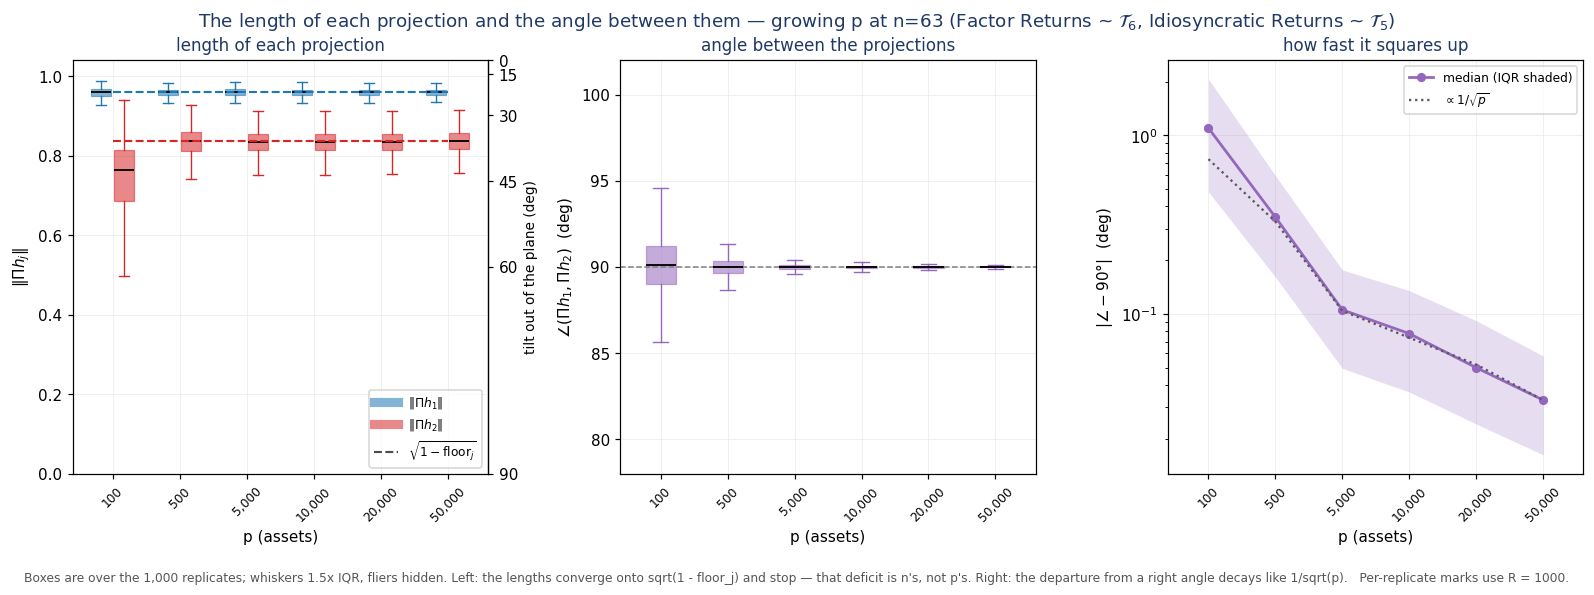

In [6]:
def frame_decomposition(d):
    """Polar-decompose each replicate's projected 2-frame C = [<b_i, h_j>] = R(theta) S.

    Returns one row per (rep, p) with the two principal angles between span(h_1, h_2)
    and span(b_1, b_2), the in-plane rotation angle, and the angle between the two
    projected vectors themselves.
    """
    w = d.pivot_table(index=["rep", "p"], columns="j", values=["hb1", "hb2", "floor"])
    w.columns = [f"{a}_j{b}" for a, b in w.columns]
    w = w.reset_index()
    C = np.empty((len(w), 2, 2))                  # column j = Pi h_j in the b basis
    C[:, 0, 0], C[:, 1, 0] = w.hb1_j1, w.hb2_j1
    C[:, 0, 1], C[:, 1, 1] = w.hb1_j2, w.hb2_j2
    U, S, Vt = np.linalg.svd(C)
    Rot = U @ Vt                                  # the rotation factor of C = R S
    Ssym = np.einsum("nji,nj,nkj->nik", Vt, S, Vt.transpose(0, 2, 1))   # S = V diag(s) V^T
    u, v = C[:, :, 0], C[:, :, 1]
    cos_pair = (u * v).sum(1) / (np.linalg.norm(u, axis=1) * np.linalg.norm(v, axis=1))
    return w.assign(
        pa1=np.degrees(np.arccos(np.clip(S[:, 0], -1, 1))),      # smaller principal angle
        pa2=np.degrees(np.arccos(np.clip(S[:, 1], -1, 1))),      # larger principal angle
        frame_rot=np.degrees(np.arctan2(Rot[:, 1, 0], Rot[:, 0, 0])),
        pair_angle=np.degrees(np.arccos(np.clip(cos_pair, -1, 1))),
        pa1_pred=np.degrees(np.arccos(np.sqrt(1 - w.floor_j1))),
        pa2_pred=np.degrees(np.arccos(np.sqrt(1 - w.floor_j2))),
        lead_align=np.abs(Vt[:, 0, 0]),           # is the leading singular direction h_1?
        s11=Ssym[:, 0, 0], s22=Ssym[:, 1, 1], s12=Ssym[:, 0, 1],   # the shrink factor S
        r1=np.linalg.norm(u, axis=1), r2=np.linalg.norm(v, axis=1),
    )


FRAME = frame_decomposition(df)
# phi_1 belongs to h_1 and phi_2 to h_2: the leading right-singular vector is h_1 in
# essentially every replicate, so the singular values pair with the factors in order.
_pa = (FRAME.melt(id_vars=["rep", "p"], value_vars=["pa1", "pa2"],
                  var_name="_j", value_name="pa")
            .assign(j=lambda t: t["_j"].str[-1].astype(int)).drop(columns="_j"))
df = df.merge(_pa, on=["rep", "p", "j"], how="left")
df = df.merge(FRAME[["rep", "p", "frame_rot", "pair_angle"]], on=["rep", "p"], how="left")

print(f"leading right-singular vector aligned with h_1: |v_11| mean "
      f"{FRAME.lead_align.mean():.4f}, min {FRAME.lead_align.min():.4f}")
print(f"largest principal angle ever seen: {FRAME.pa2.max():.3f} deg "
      f"({100 * (FRAME.pa2 < 90).mean():.2f}% of cells strictly below 90)")
print(f"angle(Pi h_1, Pi h_2): mean {FRAME.pair_angle.mean():.3f} deg, "
      f"{100 * (FRAME.pair_angle < 90).mean():.1f}% below 90 (a coin flip — not a.s. below)")
print("\nthe shrink factor S = V diag(sigma) V^T in the (h_1, h_2) basis — "
      "off-diagonal is the shear:")
_S = FRAME.groupby("p")[["s11", "s22", "s12"]].agg(["mean", "std"]).round(4)
_S.index = [f"{v:,}" for v in _S.index]
display(_S)


def _box(ax, col, color, offset=0.0, width=0.3):
    bp = ax.boxplot([FRAME[FRAME.p == v][col].to_numpy() for v in P_STEPS],
                    positions=np.arange(len(P_STEPS)) + offset, widths=width,
                    showfliers=False, patch_artist=True,
                    medianprops=dict(color="black", lw=1.2))
    for b in bp["boxes"]:
        b.set(facecolor=color, alpha=0.55, lw=0.8, edgecolor=color)
    for part in ("whiskers", "caps"):
        for a in bp[part]:
            a.set(color=color, lw=0.9)


_x = np.arange(len(P_STEPS))
FRAME["dev"] = (FRAME.pair_angle - 90).abs()
fig, axes = plt.subplots(1, 3, figsize=(14.6, 4.9))

# (1) the two lengths, against the floor they converge to
_box(axes[0], "r1", _C1, -0.17)
_box(axes[0], "r2", _C2, +0.17)
for _c, _col in (("floor_j1", _C1), ("floor_j2", _C2)):
    axes[0].plot(_x, [np.sqrt(1 - FRAME[FRAME.p == v][_c]).mean() for v in P_STEPS],
                 "--", color=_col, lw=1.4, zorder=5)
axes[0].set_ylim(0, 1.04)
axes[0].set_ylabel(r"$\Vert \Pi h_j \Vert$")
axes[0].set_title("length of each projection", color=THEME.navy, fontsize=11)
axes[0].legend(fontsize=8, loc="lower right", handles=[
    plt.Line2D([], [], color=_C1, lw=6, alpha=0.55, label=r"$\Vert \Pi h_1 \Vert$"),
    plt.Line2D([], [], color=_C2, lw=6, alpha=0.55, label=r"$\Vert \Pi h_2 \Vert$"),
    plt.Line2D([], [], color="0.3", ls="--", lw=1.4, label=r"$\sqrt{1-\mathrm{floor}_j}$")])
_sec = axes[0].secondary_yaxis(
    "right", functions=(lambda r: np.degrees(np.arccos(np.clip(r, 0, 1))),
                        lambda a: np.cos(np.radians(a))))
_sec.set_ylabel("tilt out of the plane (deg)", fontsize=9)
_sec.set_yticks([0, 15, 30, 45, 60, 90])

# (2) the angle itself
_box(axes[1], "pair_angle", "tab:purple", 0.0, 0.45)
axes[1].axhline(90, color="0.5", ls="--", lw=1.0)
axes[1].set_ylim(78, 102)
axes[1].set_ylabel(r"$\angle(\Pi h_1, \Pi h_2)$  (deg)")
axes[1].set_title("angle between the projections", color=THEME.navy, fontsize=11)

# (3) the rate it squares up at
_q = FRAME.groupby("p").dev.quantile([0.25, 0.5, 0.75]).unstack()
axes[2].fill_between(_x, _q[0.25], _q[0.75], color="tab:purple", alpha=0.22, lw=0)
axes[2].plot(_x, _q[0.5], "-o", color="tab:purple", lw=1.8, ms=5,
             label="median (IQR shaded)")
axes[2].plot(_x, _q[0.5].iloc[-1] * np.sqrt(P_STEPS[-1] / np.array(P_STEPS, dtype=float)),
             ":", color="0.35", lw=1.5, label=r"$\propto 1/\sqrt{p}$")
axes[2].set_yscale("log")
axes[2].set_ylabel(r"$|\angle - 90°|$  (deg)")
axes[2].set_title("how fast it squares up", color=THEME.navy, fontsize=11)
axes[2].legend(fontsize=8)
_lp, _ld = np.log(np.array(P_STEPS, float)), np.log(_q[0.5].to_numpy())
print(f"log-log slope of median |angle - 90| against p: {np.polyfit(_lp, _ld, 1)[0]:.3f} "
      f"(all p), {np.polyfit(_lp[2:], _ld[2:], 1)[0]:.3f} (p >= 5,000); "
      "-0.5 is the independent-residual prediction")

for ax in axes:
    ax.set_xticks(_x)
    ax.set_xticklabels([f"{v:,}" for v in P_STEPS], rotation=45, fontsize=8)
    ax.set_xlabel("p (assets)")
    ax.grid(True, color="0.92", lw=0.5)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.6, len(_x) - 0.4)
fig.tight_layout()
finish(fig,
       rf"The length of each projection and the angle between them — growing p at n=63 {_TAILS}",
       "Boxes are over the 1,000 replicates; whiskers 1.5x IQR, fliers hidden. Left: the "
       "lengths converge onto sqrt(1 - floor_j) and stop — that deficit is n's, not p's. "
       "Right: the departure from a right angle decays like 1/sqrt(p).",
       stem="ex10_length_and_angle", y=1.02)

## The $k$-frame angle, for general $k$

At $k=2$ "the angle between the frames" was ambiguous enough to be worth pinning down; at
general $k$ the answer is standard and it is what generalises. Let $B$ be the $k\times p$
population frame (orthonormal rows $b_i$) and $H$ the $p\times k$ estimates (orthonormal
columns $h_j$), and form the $k\times k$ matrix

$$C = BH, \qquad C_{ij} = \langle b_i, h_j\rangle$$

which is the projected frame written in the $b$ basis. Everything comes out of it:

| quantity | how | count |
|---|---|---|
| **principal angles** $\varphi_1 \le \dots \le \varphi_k$ between $\mathrm{span}(h)$ and $\mathrm{span}(b)$ | $\varphi_i = \arccos \sigma_i$, the singular values of $C$ | $k$ |
| **length** of each projection | $\lVert\Pi h_j\rVert = \lVert C_{\cdot j}\rVert$, the column norms | $k$ |
| **pairwise angles** between projected vectors | $\cos\angle(\Pi h_i, \Pi h_j) = G_{ij}/\sqrt{G_{ii}G_{jj}}$, $\;G = C^{\mathsf T}C$ | $k(k-1)/2$ |
| **frame rotation** | $R = UV^{\mathsf T}$ from $C = R\,S$, an element of $SO(k)$ | $k(k-1)/2$ parameters |

The principal angles are the canonical answer, always in $[0, \pi/2]$, and they are what
$\sin^2$ summaries aggregate: $\lVert P_H - P_B\rVert_F^2 = 2\sum_i \sin^2\varphi_i$.

Two things to carry over. First, **lengths and principal angles are different objects that
happen to coincide here.** $\sigma_i$ are the singular values, $\lVert C_{\cdot j}\rVert$ the
column norms; they agree exactly only when $C$'s shrink factor is diagonal in the $h$ basis,
i.e. when the shear vanishes — which is what near-orthogonality of the projected frame *means*
and why it is worth measuring separately rather than assumed. Second, **the frame rotation
stops being one number.** At $k=2$, $SO(2)$ has one parameter, which is why $\theta$ was a
scalar; at $k=3$ it is three, so "the rotation" needs an axis-angle or a set of angles, not a
single tilt.

The helper below is written for any $k$ and is checked against the $k=2$ numbers above. Run
on `ex-6`'s $k=3$ sweep it gives principal angles of $16.0°$, $32.9°$, $41.8°$ (medians at
$p=50{,}000$), with all three pairwise angles centred on $90°$ and spreads of $0.05°$,
$0.07°$, $0.16°$ — the same picture, one factor deeper.

In [7]:
def frame_angles(C):
    """Every angle between an estimated k-frame and the population k-frame.

    ``C`` is (..., k, k) with ``C[..., i, j] = <b_i, h_j>`` — the projected frame in
    the b basis. Works for any k; nothing here is specialised to k = 2.
    """
    C = np.asarray(C, dtype=float)
    k = C.shape[-1]
    U, sig, Vt = np.linalg.svd(C)
    G = np.einsum("...ij,...ik->...jk", C, C)              # Gram of the projected frame
    nrm = np.sqrt(np.einsum("...jj->...j", G))
    iu = np.triu_indices(k, 1)
    cos_pair = G[..., iu[0], iu[1]] / (nrm[..., iu[0]] * nrm[..., iu[1]])
    return {
        "principal_deg": np.degrees(np.arccos(np.clip(sig, -1, 1))),   # k canonical angles
        "length": nrm,                                                 # ||Pi h_j||
        "pair_deg": np.degrees(np.arccos(np.clip(cos_pair, -1, 1))),   # k(k-1)/2 angles
        "pair_index": list(zip(*iu)),
        "rotation": U @ Vt,                                            # R in C = R S
        "shrink": np.einsum("...ji,...j,...kj->...ik", Vt, sig, Vt.transpose(*range(C.ndim - 2), -1, -2)),
    }


# check it reproduces what Figure 2 measured
_Ck = np.empty((len(FRAME), 2, 2))
_Ck[:, 0, 0], _Ck[:, 1, 0] = FRAME.hb1_j1, FRAME.hb2_j1
_Ck[:, 0, 1], _Ck[:, 1, 1] = FRAME.hb1_j2, FRAME.hb2_j2
_fa = frame_angles(_Ck)
print("frame_angles() against the k=2 quantities used above (max abs difference):")
print(f"  principal angles : {np.abs(_fa['principal_deg'] - FRAME[['pa1', 'pa2']].to_numpy()).max():.2e} deg")
print(f"  lengths          : {np.abs(_fa['length'] - FRAME[['r1', 'r2']].to_numpy()).max():.2e}")
print(f"  pairwise angle   : {np.abs(_fa['pair_deg'][:, 0] - FRAME.pair_angle.to_numpy()).max():.2e} deg")
print(f"  shear S_12       : {np.abs(_fa['shrink'][:, 0, 1] - FRAME.s12.to_numpy()).max():.2e}")

frame_angles() against the k=2 quantities used above (max abs difference):
  principal angles : 0.00e+00 deg
  lengths          : 1.11e-16
  pairwise angle   : 1.42e-14 deg
  shear S_12       : 0.00e+00


## The seven exemplars

Figure 3 draws one clock face per replicate, which means choosing a handful. E1–E7 are the
replicates at the 2nd, 16th, 34th, 50th, 66th, 84th and 98th percentile of $\theta_\infty$ —
the limiting rotation of the frame — so they span the range of behaviour without being
outliers. Each keeps one `tab10` colour throughout.

In [8]:
_lim = df.groupby("rep").theta_lim.first().sort_values()
EX_QS = (0.02, 0.16, 0.34, 0.50, 0.66, 0.84, 0.98)
EX = [int(_lim.index[int(round(q * (len(_lim) - 1)))]) for q in EX_QS]
EX_NAME = {r: f"E{i + 1}" for i, r in enumerate(EX)}
EX_COL = dict(zip(EX, plt.get_cmap("tab10").colors))

_ex = pd.DataFrame({"rep": EX, "theta_inf (deg)": _lim.loc[EX].round(2).to_numpy()},
                   index=[EX_NAME[r] for r in EX])
_ex["pctile of theta_inf"] = [f"{100 * q:.0f}" for q in EX_QS]
display(_ex)

,rep,theta_inf (deg),pctile of theta_inf
E1,238,-9.30,2
E2,590,-4.02,16
E3,814,-1.56,34
E4,139,0.14,50
E5,290,1.85,66
E6,331,4.17,84
E7,485,9.98,98


## Figure 3 — one clock face per replicate: the pair drawn as two hands

Figure 4 superimposes the two estimates so they share one wedge, which is what makes 1,000
pairs legible at once — but it also means you never see a pair in its own coordinates. Here
each replicate gets its **own clock face**, in the untransformed $(b_1, b_2)$ plane: the grey
hands are the true frame $(b_1, b_2)$ at unit length, the coloured hands are that replicate's
$(\Pi h_1, \Pi h_2)$, and the shaded wedge is the angle between them. Rows walk $p$, columns
are the seven exemplars.

**What to look for:** three separate things, all visible at a glance on one face.

1. **Rotation.** The whole coloured pair is turned off the grey pair by $\theta$ — clockwise
   for E1, anticlockwise for E7, barely at all for E4. That turn does not shrink as $p$ grows;
   it settles onto the replicate's own $\theta_\infty$.
2. **Shrink.** Both coloured hands are *shorter* than their grey counterparts, and the $b_2$
   hand is much shorter than the $b_1$ hand ($0.84$ vs $0.96$) — those two deficits are
   $\cos\varphi_2$ and $\cos\varphi_1$, the principal angles of Figure 2. They do not shrink
   with $p$ either; they are $n$'s floor.
3. **Squareness.** The printed $\angle$ is the angle between the two coloured hands. At
   $p=100$ it is visibly off square (E5 at $94.1°$, E3 at $86.9°$); by $p=50{,}000$ every face
   reads $90.0°$ to a tenth of a degree. That is the pair becoming rigid — the only one of the three effects that
   growing $p$ actually fixes.

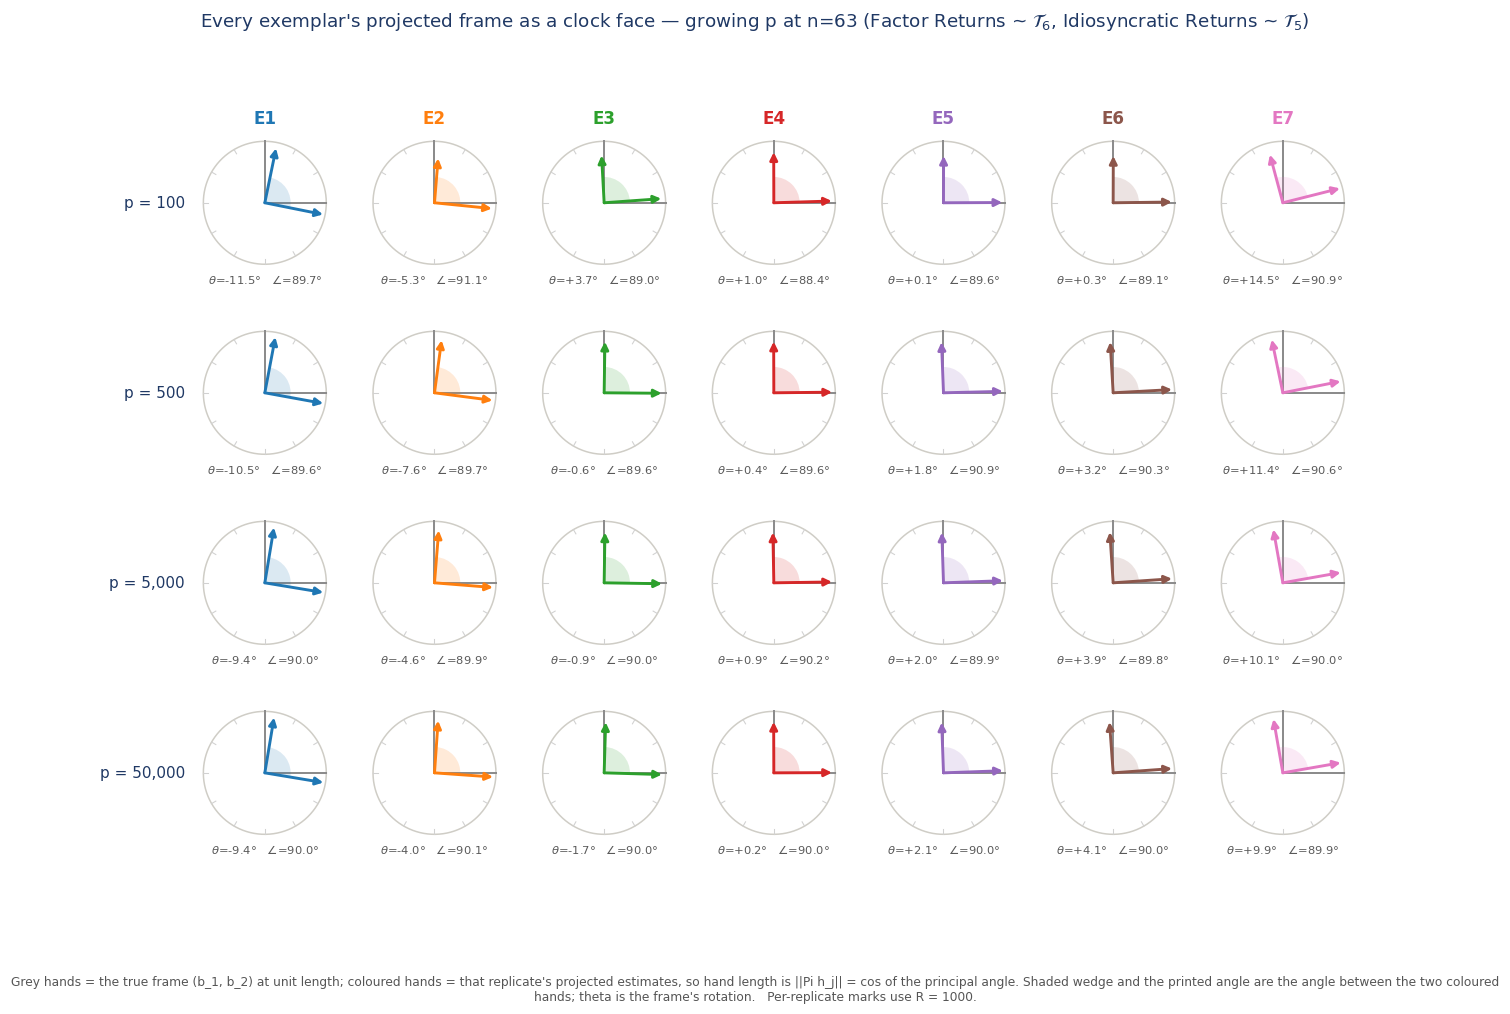

In [9]:
from matplotlib.patches import Wedge

_FACE_P = [100, 500, 5000, P_MAX]


def clock_face(ax, e, colour):
    """One replicate's projected frame as two hands against the true frame."""
    t = np.linspace(0, 2 * np.pi, 300)
    ax.plot(np.cos(t), np.sin(t), color="#CFCDC6", lw=1.0, zorder=1)
    for a in np.arange(0, 360, 30):                      # hour ticks
        ax.plot([0.92 * np.cos(np.radians(a)), np.cos(np.radians(a))],
                [0.92 * np.sin(np.radians(a)), np.sin(np.radians(a))],
                color="0.82", lw=0.7, zorder=1)
    ax.plot([0, 1], [0, 0], color="0.55", lw=1.3, zorder=2)      # b_1, unit length
    ax.plot([0, 0], [0, 1], color="0.55", lw=1.3, zorder=2)      # b_2, unit length
    a1 = np.degrees(np.arctan2(e.hb2_j1, e.hb1_j1))
    a2 = np.degrees(np.arctan2(e.hb2_j2, e.hb1_j2))
    ax.add_patch(Wedge((0, 0), 0.42, min(a1, a2), max(a1, a2),
                       facecolor=colour, alpha=0.16, lw=0, zorder=2))
    for x, y in ((e.hb1_j1, e.hb2_j1), (e.hb1_j2, e.hb2_j2)):
        ax.annotate("", xy=(x, y), xytext=(0, 0), zorder=5,
                    arrowprops=dict(arrowstyle="-|>", color=colour, lw=1.9,
                                    shrinkA=0, shrinkB=0))
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.set_aspect("equal")
    ax.axis("off")
    return abs(a2 - a1)


_FACE = FRAME.set_index(["rep", "p"])

fig, axes = plt.subplots(len(_FACE_P), len(EX), figsize=(13.6, 8.6))
for ri, v in enumerate(_FACE_P):
    for ci, rep_id in enumerate(EX):
        ax = axes[ri, ci]
        e = _FACE.loc[(rep_id, v)]
        ang = clock_face(ax, e, EX_COL[rep_id])
        ax.text(0, -1.13, rf"$\theta$={e.frame_rot:+.1f}°   $\angle$={ang:.1f}°",
                fontsize=7.5, color="0.35", ha="center", va="top")
        if ri == 0:
            ax.set_title(EX_NAME[rep_id], color=EX_COL[rep_id], fontsize=11,
                         fontweight="bold")
        if ci == 0:
            ax.text(-1.30, 0, f"p = {v:,}", fontsize=10, color=THEME.navy,
                    ha="right", va="center")
finish(fig,
       rf"Every exemplar's projected frame as a clock face — growing p at n=63 {_TAILS}",
       "Grey hands = the true frame (b_1, b_2) at unit length; coloured hands = that "
       "replicate's projected estimates, so hand length is ||Pi h_j|| = cos of the "
       "principal angle. Shaded wedge and the printed angle are the angle between the "
       "two coloured hands; theta is the frame's rotation.",
       stem="ex10_clock_faces", y=1.0)

## Figure 4 — each replicate's path through the (length, angle) plane

The one view worth keeping from the identity figures: follow a named replicate as $p$ grows.
Now the space it moves through is the one we care about. Left panel: the two lengths against
each other, so a replicate's whole projected frame is one point. Right panel: the length that
actually moves, $\lVert\Pi h_2\rVert$, against how far from square the pair sits — log scale,
so the last two decades are visible. Marker size grows with $p$; the star is the predicted
destination $\sqrt{1-\text{floor}_j}$; grey is the full $p=50{,}000$ cloud.

The dashed black path is **replicate 241**, the $p=100$ extreme from Figure 1's middle row —
included because it shows the full journey rather than the last inch of it.

**What to look for:** the paths run *up and to the right* in the left panel and *down and to
the right* in the right panel, and they do both at once. Almost all of the travel happens
between $p=100$ and $p=5{,}000$; after that the markers pile up on the destination and the
remaining motion is the $1/\sqrt{p}$ crawl of the angle. Note what the left panel does **not**
show: no path drifts along the $\lVert\Pi h_1\rVert$ axis. That coordinate is fixed at $0.96$
from the start — the strong factor's length is set by $n$ and there is nothing for $p$ to do.
Replicate 241 makes the shape of the journey obvious: it enters at $\lVert\Pi h_2\rVert
= 0.203$ with the pair $65°$ off square, and one step of $p$ carries it essentially all the
way home.

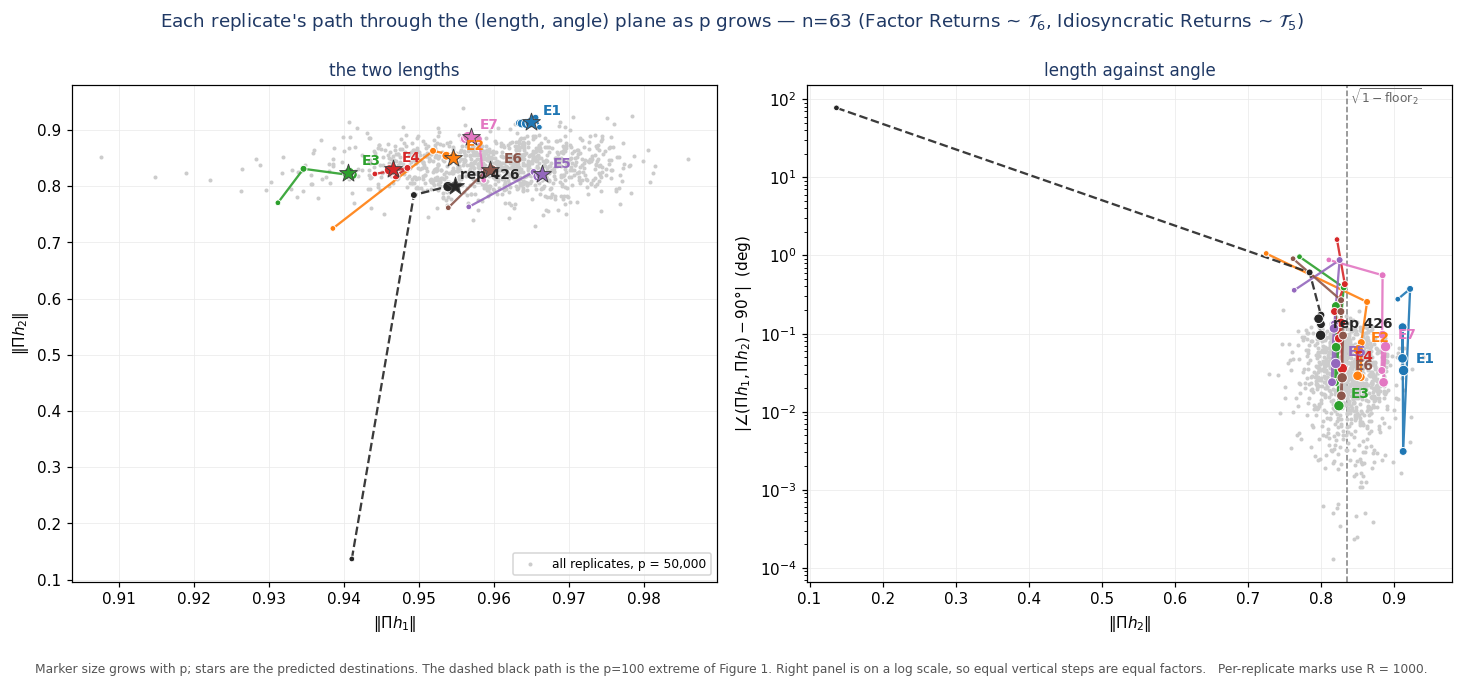

In [10]:
FRAME["adev"] = (FRAME.pair_angle - 90).abs()
FRAME["t1"] = np.sqrt(1 - FRAME.floor_j1)
FRAME["t2"] = np.sqrt(1 - FRAME.floor_j2)
_a100 = FRAME[FRAME.p == 100]
_REP_X = int(_a100.loc[_a100.pair_angle.idxmax(), "rep"])
_endF = FRAME[FRAME.p == P_MAX]

fig, axes = plt.subplots(1, 2, figsize=(13.4, 5.9))
for ax, (xc, yc, xl, yl, ttl) in zip(axes, [
        ("r1", "r2", r"$\Vert\Pi h_1\Vert$", r"$\Vert\Pi h_2\Vert$", "the two lengths"),
        ("r2", "adev", r"$\Vert\Pi h_2\Vert$",
         r"$|\angle(\Pi h_1,\Pi h_2)-90°|$  (deg)", "length against angle")]):
    ax.scatter(_endF[xc], _endF[yc], s=7, color="0.80", lw=0, zorder=2,
               label=f"all replicates, p = {P_MAX:,}")
    for _rep in EX + [_REP_X]:
        tr = FRAME[FRAME.rep == _rep].sort_values("p")
        _is_ex = _rep in EX
        col = EX_COL[_rep] if _is_ex else "0.15"
        ax.plot(tr[xc], tr[yc], "-" if _is_ex else "--", color=col, lw=1.5, alpha=0.9, zorder=4)
        ax.scatter(tr[xc], tr[yc], s=np.linspace(14, 46, len(tr)), color=col, lw=0.6,
                   edgecolor="white", zorder=5)
        e = tr.iloc[-1]
        if yc == "r2":
            ax.scatter([e.t1], [e.t2], marker="*", s=150, color=col, edgecolor="0.25",
                       lw=0.6, zorder=6)
        ax.annotate(EX_NAME[_rep] if _is_ex else f"rep {_rep}", (e[xc], e[yc]),
                    textcoords="offset points", xytext=(8, 5), fontsize=9, color=col,
                    fontweight="bold", zorder=7)
    if yc == "adev":
        ax.set_yscale("log")
        ax.axvline(_endF.t2.mean(), color="0.5", ls="--", lw=1.0, zorder=1)
        ax.text(_endF.t2.mean(), ax.get_ylim()[1], r" $\sqrt{1-\mathrm{floor}_2}$",
                fontsize=8, color="0.4", ha="left", va="top")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(ttl, color=THEME.navy, fontsize=11)
    ax.grid(True, color="0.92", lw=0.5)
    ax.set_axisbelow(True)
axes[0].legend(fontsize=8, loc="lower right")
fig.tight_layout(rect=(0, 0, 1, 0.93))
finish(fig,
       rf"Each replicate's path through the (length, angle) plane as p grows — n=63 {_TAILS}",
       "Marker size grows with p; stars are the predicted destinations. The dashed black "
       "path is the p=100 extreme of Figure 1. Right panel is on a log scale, so equal "
       "vertical steps are equal factors.",
       stem="ex10_length_angle_paths", y=0.985)

## The numbers behind the pictures

Three tables: how fast a replicate's tilt locks onto its own limit, the exemplars' actual
coordinates panel by panel, and the radial half of the story — the floor that growing $p$
never removes.

In [11]:
print("Per-replicate convergence: RMS |theta_j - theta_inf| in degrees, and the share of "
      "replicates already within 1 degree of their own limit.")
_conv = df.assign(err=(df.tilt - df.theta_lim).abs()).groupby(["p", "j"]).agg(
    rms_deg=("err", lambda s: float(np.sqrt((s ** 2).mean()))),
    median_deg=("err", "median"),
    within_1deg_pct=("err", lambda s: 100.0 * (s < 1.0).mean()),
).round(2).unstack()
_conv.index = [f"{v:,}" for v in _conv.index]
display(_conv)

print("\nThe exemplars in full: signed tilt (deg) and in-plane radius, per p.")
_tab = (df[df.rep.isin(EX)]
        .assign(name=df.rep.map(EX_NAME))
        .pivot_table(index=["name", "j"], columns="p", values=["tilt", "rad"])
        .round(3)
        .reindex([EX_NAME[r] for r in EX], level=0))
_tab.columns = pd.MultiIndex.from_tuples([(a, f"{b:,}") for a, b in _tab.columns])
display(_tab)

print("\nThe radial half: growing p removes the p-noise but not the n-driven floor. "
      "Mean over replicates.")
_rad = df.groupby(["p", "j"]).agg(
    radius=("rad", "mean"), radius_sd=("rad", "std"),
    floor_implied_radius=("floor", lambda s: float(np.sqrt(1 - s).mean())),
    oos=("oos", "mean"),
).round(4).unstack()
_rad.index = [f"{v:,}" for v in _rad.index]
display(_rad)

print("\nThe reference frame is itself moving: |<b_1, l_2>| is the tilt of the population "
      "eigen-frame off the loading rows, O(1/sqrt(p)).")
_ft = df.groupby("p").frame_tilt.mean().round(4)
_ft.index = [f"{v:,}" for v in _ft.index]
display(_ft.to_frame("mean |<b_1, l_2>|"))

Per-replicate convergence: RMS |theta_j - theta_inf| in degrees, and the share of replicates already within 1 degree of their own limit.


rms_deg       median_deg       within_1deg_pct       
j            1     2          1     2               1      2
100       3.10  9.05       1.65  2.32            29.8   23.7
500       1.26  1.74       0.73  0.85            62.6   57.4
5,000     0.37  0.42       0.22  0.26            98.6   97.9
10,000    0.27  0.31       0.16  0.19            99.9   99.9
20,000    0.19  0.21       0.11  0.13            99.9   99.9
50,000    0.11  0.13       0.07  0.08           100.0  100.0


The exemplars in full: signed tilt (deg) and in-plane radius, per p.


rad                                       tilt                  \
          100    500  5,000 10,000 20,000 50,000     100     500   5,000   
name j                                                                     
E1   1  0.966  0.966  0.963  0.964  0.964  0.965 -11.348 -10.324  -9.391   
     2  0.905  0.922  0.912  0.911  0.911  0.913 -11.623 -10.697  -9.388   
E2   1  0.939  0.952  0.955  0.954  0.955  0.955  -5.752  -7.433  -4.560   
     2  0.725  0.863  0.855  0.854  0.850  0.851  -4.693  -7.686  -4.637   
E3   1  0.931  0.935  0.941  0.940  0.941  0.941   4.100  -0.463  -0.923   
     2  0.770  0.831  0.820  0.820  0.820  0.824   3.139  -0.851  -0.900   
E4   1  0.944  0.948  0.947  0.946  0.946  0.946   1.721   0.601   0.859   
     2  0.822  0.832  0.818  0.824  0.827  0.829   0.127   0.172   1.050   
E5   1  0.957  0.965  0.966  0.966  0.966  0.966   0.240   1.392   2.035   
     2  0.763  0.825  0.818  0.815  0.818  0.820  -0.118   2.264   1.902   
E6   1  0.954  0.959  0.960  0.960  0.960  0.960   0.735   3.116   3.960   
     2  0.762  0.827  0.827  0.830  0.828  0.829  -0.172   3.383   3.769   
E7   1  0.959  0.958  0.956  0.956  0.957  0.957  14.141  11.164  10.085   
     2  0.811  0.884  0.883  0.884  0.885  0.888  15.017  11.721  10.052   

                              
        10,000 20,000 50,000  
name j                        
E1   1  -9.386 -9.138 -9.432  
     2  -9.506 -9.186 -9.465  
E2   1  -4.262 -4.212 -4.064  
     2  -4.290 -4.241 -4.002  
E3   1  -1.033 -1.561 -1.696  
     2  -0.808 -1.494 -1.708  
E4   1   0.531  0.717  0.213  
     2   0.617  0.854  0.178  
E5   1   1.773  1.890  2.032  
     2   1.797  2.006  2.073  
E6   1   3.938  4.070  4.142  
     2   3.843  4.054  4.115  
E7   1  10.078  9.900  9.906  
     2   9.981  9.877  9.838


The radial half: growing p removes the p-noise but not the n-driven floor. Mean over replicates.


radius         radius_sd         floor_implied_radius             oos  \
j            1       2         1       2                    1       2       1   
100     0.9570  0.7234    0.0264  0.1476               0.9594  0.8354  0.0834   
500     0.9585  0.8318    0.0107  0.0463               0.9594  0.8354  0.0811   
5,000   0.9592  0.8329    0.0101  0.0314               0.9594  0.8354  0.0798   
10,000  0.9592  0.8335    0.0101  0.0310               0.9594  0.8354  0.0799   
20,000  0.9592  0.8336    0.0100  0.0309               0.9594  0.8354  0.0798   
50,000  0.9592  0.8356    0.0100  0.0304               0.9594  0.8354  0.0798   

                
j            2  
100     0.4549  
500     0.3060  
5,000   0.3054  
10,000  0.3043  
20,000  0.3041  
50,000  0.3008


The reference frame is itself moving: |<b_1, l_2>| is the tilt of the population eigen-frame off the loading rows, O(1/sqrt(p)).


,"mean |<b_1, l_2>|"
100,0.0099
500,0.0159
"5,000",0.0144
"10,000",0.0081
"20,000",0.0025
"50,000",0.0027
